In [1]:
# ── Cell 1: Install & Import ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Prettier plots
sns.set_theme(style="whitegrid", palette="Set2")
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# ── Cell 2: Load Dataset ──────────────────────────────────────────────
iris = load_iris()

# Convert to DataFrame for easy exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# ── Cell 3: Basic Statistics ──────────────────────────────────────────
print("Dataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
df.describe().round(2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [4]:
# ── Cell 4: Check class balance ───────────────────────────────────────
print("Class distribution:")
print(df['species'].value_counts())
# Expected: 50 samples per class — perfectly balanced!

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


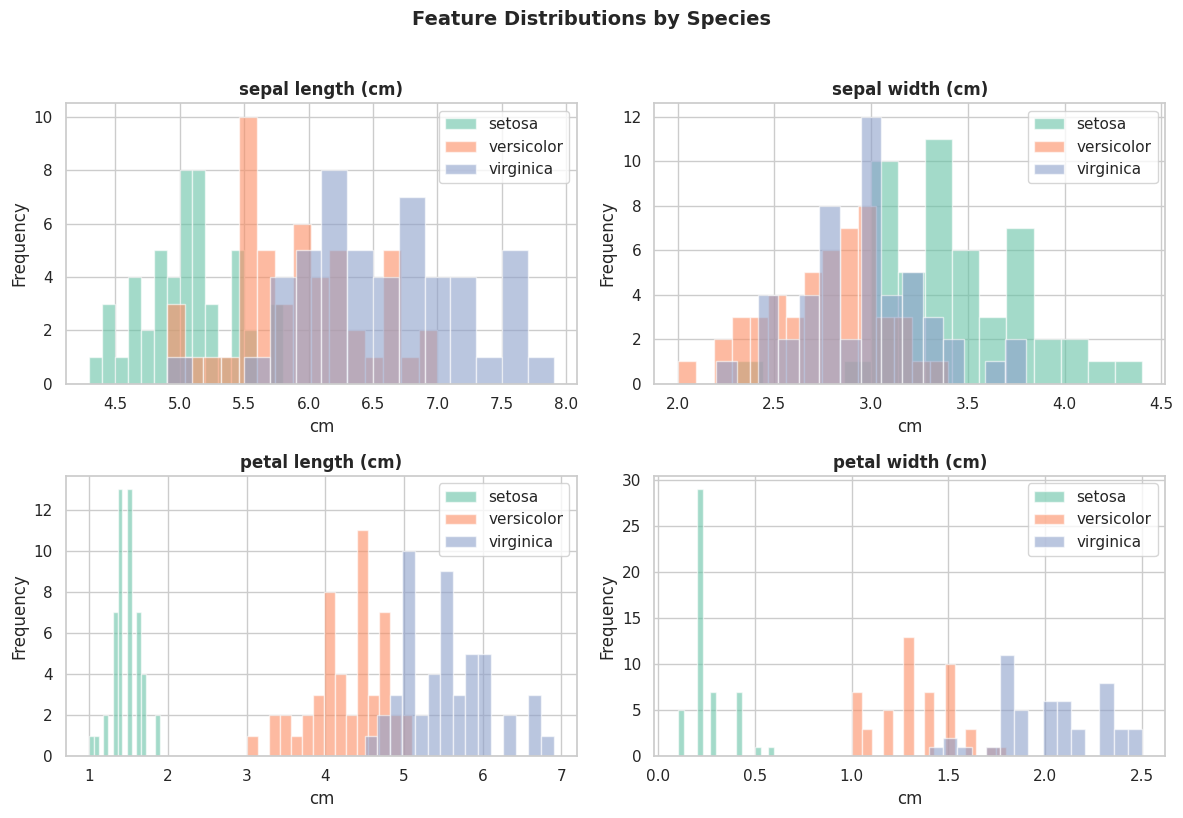

In [5]:
# ── Cell 5: Histograms for each feature ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, (ax, feat) in enumerate(zip(axes.flatten(), features)):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[feat], alpha=0.6, label=species, bins=15)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel("cm")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Feature Distributions by Species", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

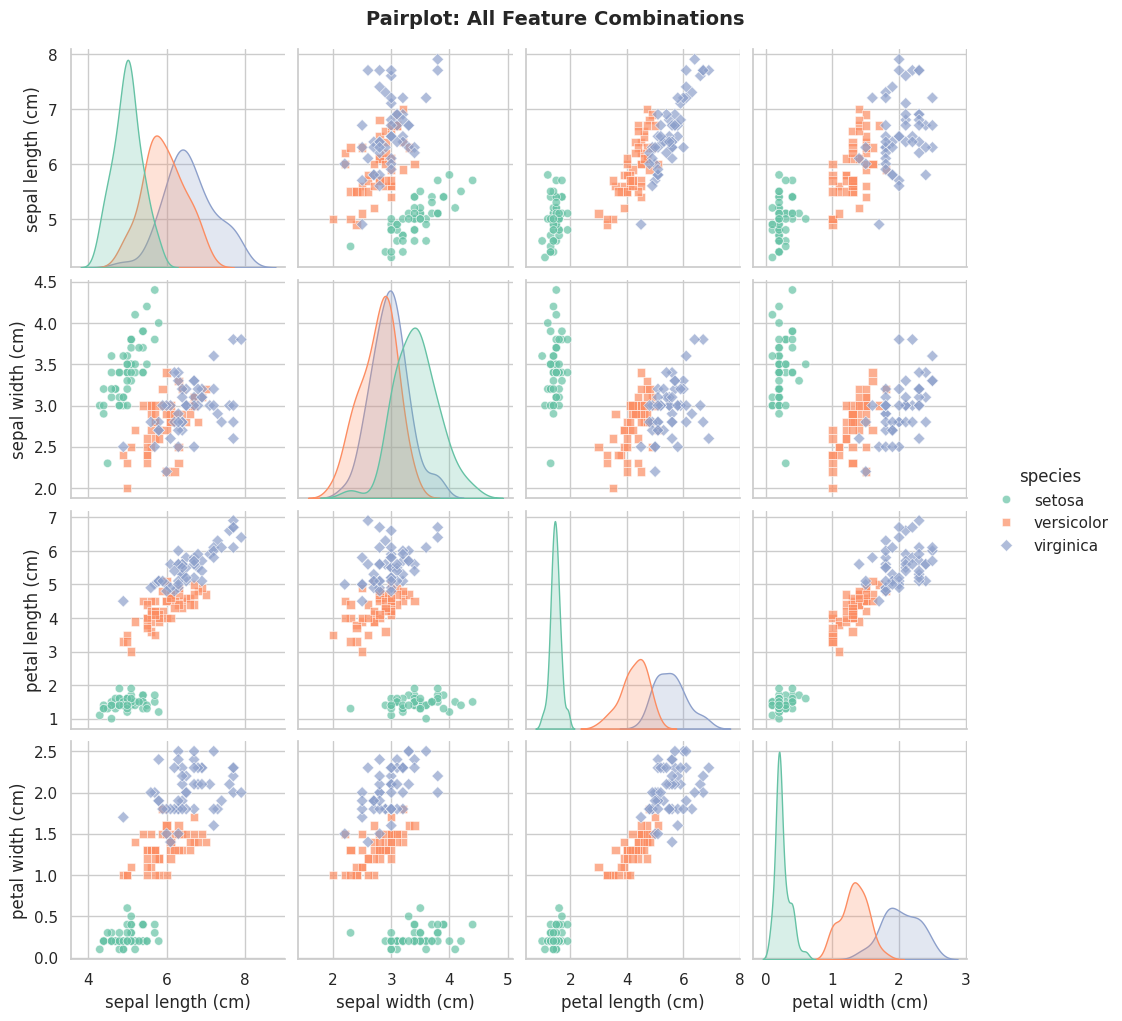

In [6]:
# ── Cell 6: Scatter Plot Matrix (Pairplot) ────────────────────────────
sns.pairplot(df, hue='species', diag_kind='kde', markers=['o', 's', 'D'],
             plot_kws={'alpha': 0.7})
plt.suptitle("Pairplot: All Feature Combinations", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# KEY INSIGHT: petal length & petal width separate species best!

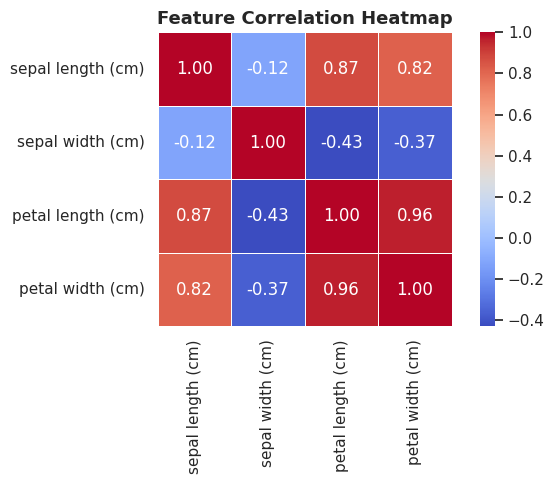

In [8]:
# ── Cell 7: Correlation Heatmap ───────────────────────────────────────
plt.figure(figsize=(7, 5))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9765/6108462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9765/6108462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9765/6108462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9765/6108462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

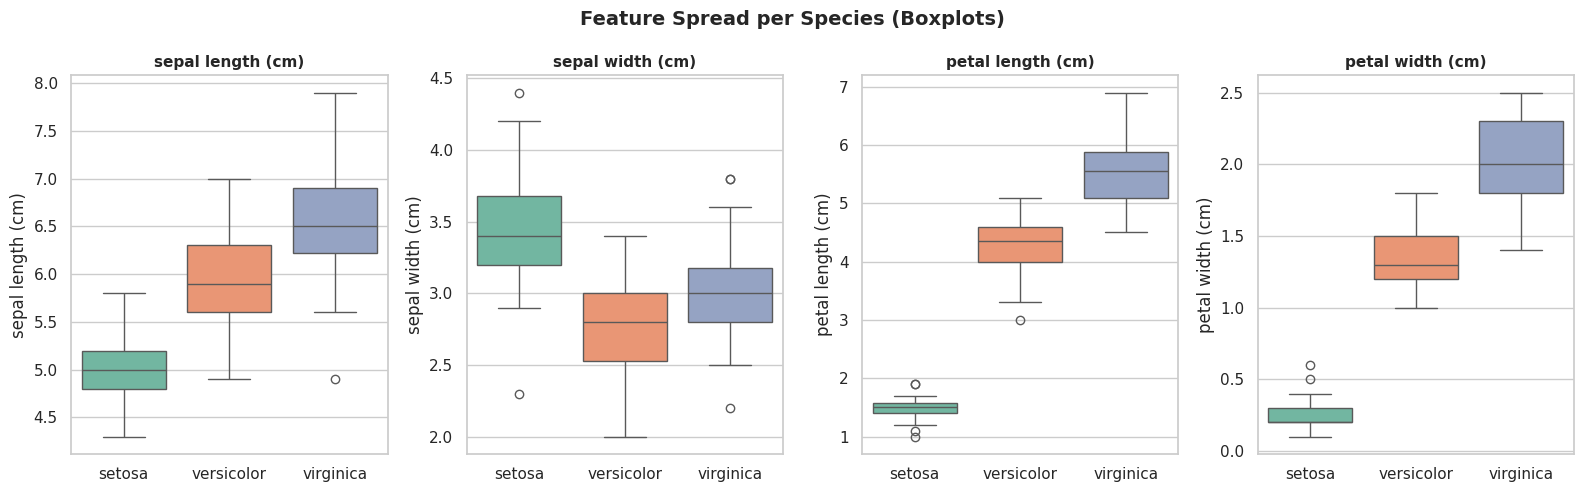

In [9]:
# ── Cell 8: Boxplots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel("")

plt.suptitle("Feature Spread per Species (Boxplots)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Cell 9: Split Data ────────────────────────────────────────────────
X = df.drop('species', axis=1)
y = iris.target   # 0=Setosa, 1=Versicolor, 2=Virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Class balance in test set: {np.bincount(y_test)}")

Training samples : 120
Testing  samples : 30
Class balance in test set: [10 10 10]


In [11]:
# ── Cell 10: Feature Scaling (needed for LR & KNN) ───────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print("✅ Scaling complete. Mean ~0, Std ~1 on training features.")

✅ Scaling complete. Mean ~0, Std ~1 on training features.


In [12]:
# ── Cell 11: Define & Train Models ───────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"✅ {name:25s} → Accuracy: {acc*100:.2f}%")

✅ Logistic Regression       → Accuracy: 93.33%
✅ K-Nearest Neighbors       → Accuracy: 93.33%
✅ Decision Tree             → Accuracy: 93.33%


In [13]:
# ── Cell 12: Full Classification Reports ─────────────────────────────
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(
        y_test, res['y_pred'],
        target_names=iris.target_names
    ))


  Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


  K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


  Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica

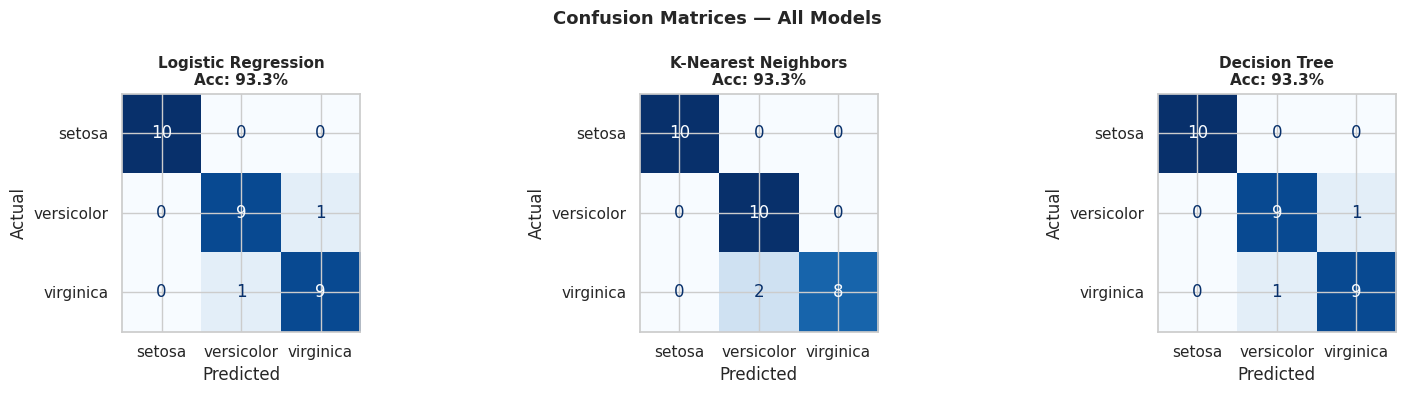

In [14]:
# ── Cell 13: Confusion Matrices (side by side) ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']*100:.1f}%",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

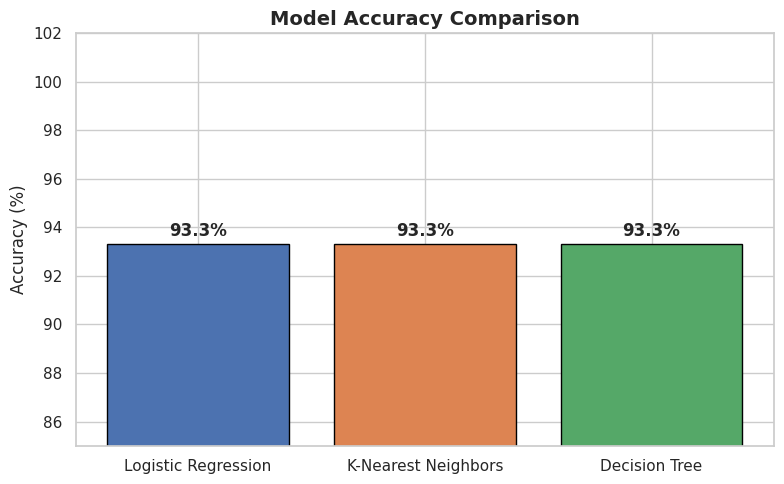

In [15]:
# ── Cell 14: Accuracy Comparison Bar Chart ────────────────────────────
names = list(results.keys())
accs  = [res['accuracy'] * 100 for res in results.values()]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
plt.ylim(85, 102)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{acc:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

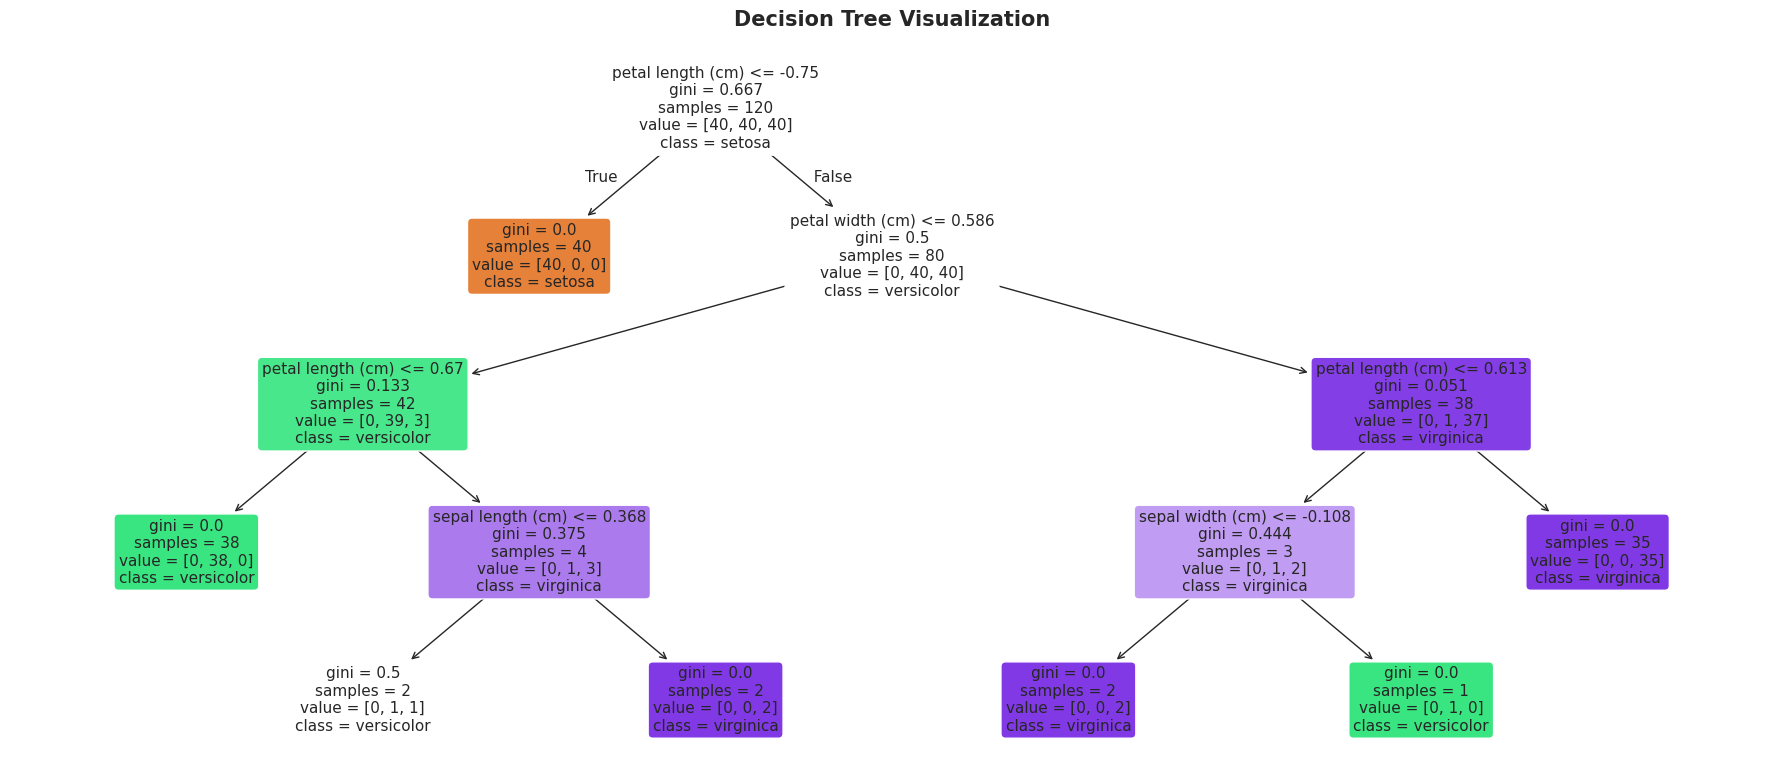

In [16]:
# ── Cell 15: Plot Decision Tree ───────────────────────────────────────
dt_model = results["Decision Tree"]["model"]

plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=11
)
plt.title("Decision Tree Visualization", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ── Cell 16: Predict Custom Input ─────────────────────────────────────
# Format: [sepal_length, sepal_width, petal_length, petal_width] in cm
sample_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],   # likely Setosa
    [6.0, 2.9, 4.5, 1.5],   # likely Versicolor
    [6.7, 3.1, 5.6, 2.4],   # likely Virginica
])

sample_scaled = scaler.transform(sample_flowers)

print(f"{'Measurements':<40} {'LR':<15} {'KNN':<15} {'DT'}")
print("-" * 85)

for flower, scaled in zip(sample_flowers, sample_scaled):
    preds = {name: iris.target_names[res['model'].predict([scaled])[0]]
             for name, res in results.items()}
    print(f"{str(flower):<40} {preds['Logistic Regression']:<15} "
          f"{preds['K-Nearest Neighbors']:<15} {preds['Decision Tree']}")

Measurements                             LR              KNN             DT
-------------------------------------------------------------------------------------
[5.1 3.5 1.4 0.2]                        setosa          setosa          setosa
[6.  2.9 4.5 1.5]                        versicolor      versicolor      versicolor
[6.7 3.1 5.6 2.4]                        virginica       virginica       virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
# ── Cell 17: Cross-Validation ─────────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} {'Mean Acc':>10} {'Std Dev':>10} {'Min':>8} {'Max':>8}")
print("-" * 65)

for name, res in results.items():
    scores = cross_val_score(res['model'], X_train_sc, y_train,
                             cv=kfold, scoring='accuracy')
    print(f"{name:<25} {scores.mean()*100:>9.2f}% {scores.std()*100:>9.2f}%"
          f" {scores.min()*100:>7.2f}% {scores.max()*100:>7.2f}%")

Model                       Mean Acc    Std Dev      Min      Max
-----------------------------------------------------------------
Logistic Regression           95.83%      2.64%   91.67%  100.00%
K-Nearest Neighbors           95.83%      2.64%   91.67%  100.00%
Decision Tree                 94.17%      2.04%   91.67%   95.83%


In [19]:
# ── Cell 18: GridSearchCV ─────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# --- KNN tuning ---
knn_params = {'n_neighbors': [3, 5, 7, 9, 11],
              'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params,
                        cv=5, scoring='accuracy')
knn_grid.fit(X_train_sc, y_train)
print(f"Best KNN params : {knn_grid.best_params_}")
print(f"Best KNN score  : {knn_grid.best_score_*100:.2f}%\n")

# --- Decision Tree tuning ---
dt_params = {'max_depth': [2, 3, 4, 5, None],
             'criterion': ['gini', 'entropy'],
             'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train_sc, y_train)
print(f"Best DT params  : {dt_grid.best_params_}")
print(f"Best DT score   : {dt_grid.best_score_*100:.2f}%\n")

# --- Logistic Regression tuning ---
lr_params = {'C': [0.01, 0.1, 1, 10, 100],
             'solver': ['lbfgs', 'saga']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=500, random_state=42),
                       lr_params, cv=5, scoring='accuracy')
lr_grid.fit(X_train_sc, y_train)
print(f"Best LR params  : {lr_grid.best_params_}")
print(f"Best LR score   : {lr_grid.best_score_*100:.2f}%")

Best KNN params : {'metric': 'euclidean', 'n_neighbors': 5}
Best KNN score  : 96.67%

Best DT params  : {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Best DT score   : 94.17%



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best LR params  : {'C': 10, 'solver': 'lbfgs'}
Best LR score   : 96.67%


In [20]:
# ── Cell 19: Evaluate Tuned Models ───────────────────────────────────
tuned_models = {
    "KNN (Tuned)"  : knn_grid.best_estimator_,
    "DT (Tuned)"   : dt_grid.best_estimator_,
    "LR (Tuned)"   : lr_grid.best_estimator_,
}

print(f"\n{'Model':<20} {'Accuracy':>10}")
print("-" * 32)
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:<20} {acc*100:>9.2f}%")


Model                  Accuracy
--------------------------------
KNN (Tuned)              93.33%
DT (Tuned)               93.33%
LR (Tuned)              100.00%


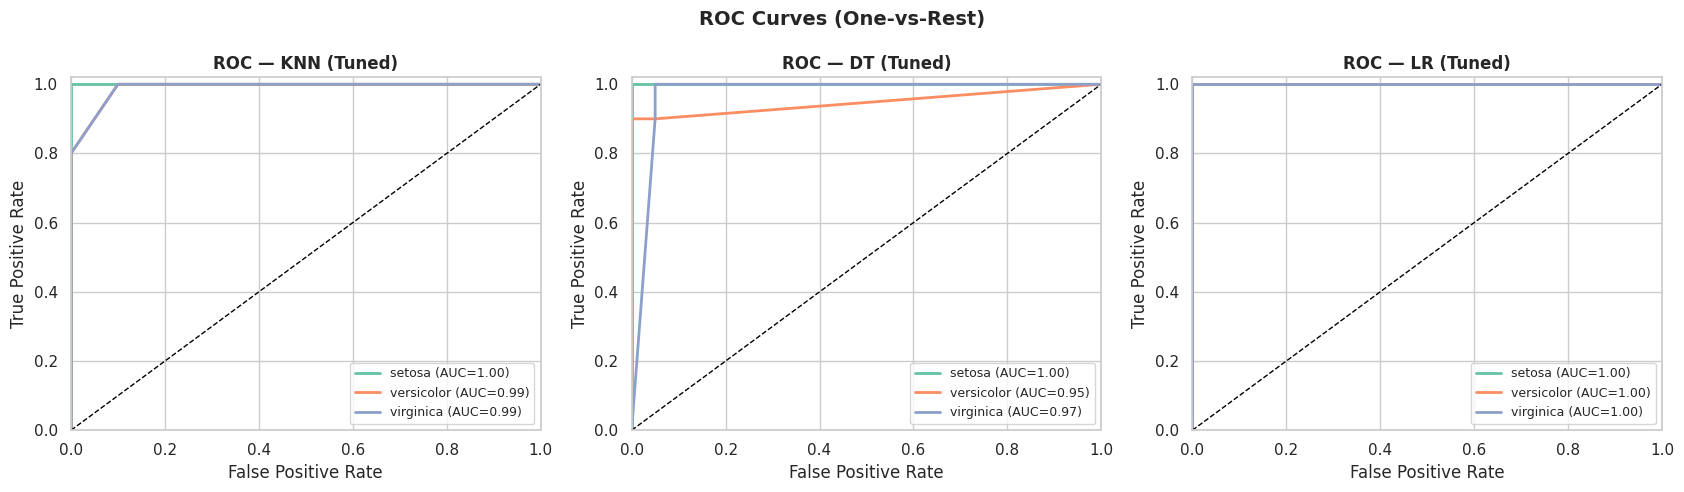

In [21]:
# ── Cell 20: ROC Curves ───────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize labels for one-vs-rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes  = 3
colors     = cycle(['#4C72B0', '#DD8452', '#55A868'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model), color in zip(axes, tuned_models.items(), colors):
    y_score = model.predict_proba(X_test_sc)
    for i, species in enumerate(iris.target_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{species} (AUC={roc_auc:.2f})")
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {name}", fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("ROC Curves (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

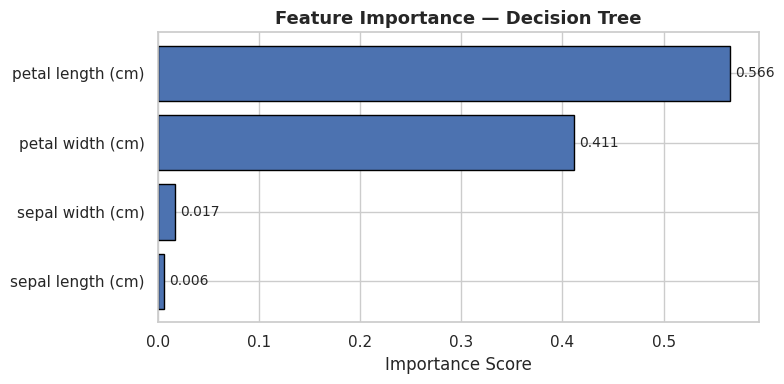

In [22]:
# ── Cell 21: Feature Importance ───────────────────────────────────────
importances = dt_grid.best_estimator_.feature_importances_
feat_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color='#4C72B0', edgecolor='black')
plt.xlabel("Importance Score")
plt.title("Feature Importance — Decision Tree", fontweight='bold', fontsize=13)
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
# ── Cell 22: Save Model & Scaler ─────────────────────────────────────
import joblib

# Save best model (use whichever scored highest — here LR)
joblib.dump(lr_grid.best_estimator_, 'iris_model.pkl')
joblib.dump(scaler,                  'iris_scaler.pkl')
print("✅ Model saved as iris_model.pkl")
print("✅ Scaler saved as iris_scaler.pkl")

# Test reload
loaded_model  = joblib.load('iris_model.pkl')
loaded_scaler = joblib.load('iris_scaler.pkl')

test_input = np.array([[5.1, 3.5, 1.4, 0.2]])
pred = loaded_model.predict(loaded_scaler.transform(test_input))
print(f"\n🌸 Test prediction: {iris.target_names[pred[0]]}")

✅ Model saved as iris_model.pkl
✅ Scaler saved as iris_scaler.pkl

🌸 Test prediction: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
# ── Cell 23: Interactive Widget ───────────────────────────────────────
from ipywidgets import interact, FloatSlider

def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    scaled = loaded_scaler.transform(sample)
    pred   = loaded_model.predict(scaled)[0]
    proba  = loaded_model.predict_proba(scaled)[0]
    print(f"\n🌸 Predicted Species : {iris.target_names[pred].upper()}")
    print(f"   Confidence        : {proba.max()*100:.1f}%")
    for name, p in zip(iris.target_names, proba):
        bar = '█' * int(p * 30)
        print(f"   {name:<12}: {bar} {p*100:.1f}%")

interact(predict_species,
    sepal_length = FloatSlider(min=4.0, max=8.0, step=0.1, value=5.8),
    sepal_width  = FloatSlider(min=2.0, max=4.5, step=0.1, value=3.0),
    petal_length = FloatSlider(min=1.0, max=7.0, step=0.1, value=3.7),
    petal_width  = FloatSlider(min=0.1, max=2.5, step=0.1, value=1.2),
)

interactive(children=(FloatSlider(value=5.8, description='sepal_length', max=8.0, min=4.0), FloatSlider(value=…

<function __main__.predict_species(sepal_length, sepal_width, petal_length, petal_width)>

In [26]:
# ── Download model files from Colab ───────────────────────────────────
from google.colab import files

files.download('iris_model.pkl')
files.download('iris_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# ── Cell: Write app.py ────────────────────────────────────────────────
app_code = '''
import streamlit as st
import numpy as np
import joblib

model  = joblib.load("iris_model.pkl")
scaler = joblib.load("iris_scaler.pkl")

species_names = ["Setosa", "Versicolor", "Virginica"]
species_emoji = ["🌼", "🌸", "🌺"]
species_info  = {
    "Setosa"    : "Small flowers with short, narrow petals.",
    "Versicolor": "Medium-sized flowers, moderate petal dimensions.",
    "Virginica" : "Largest flowers with long, wide petals."
}

st.set_page_config(page_title="Iris Flower Classifier", page_icon="🌸", layout="centered")

st.title("🌸 Iris Flower Classifier")
st.markdown("Adjust the measurements using the sliders, then click **Predict**.")
st.divider()

col1, col2 = st.columns(2)
with col1:
    st.subheader("🌿 Sepal")
    sepal_length = st.slider("Sepal Length (cm)", 4.0, 8.0, 5.8, 0.1)
    sepal_width  = st.slider("Sepal Width (cm)",  2.0, 4.5, 3.0, 0.1)
with col2:
    st.subheader("🌺 Petal")
    petal_length = st.slider("Petal Length (cm)", 1.0, 7.0, 3.7, 0.1)
    petal_width  = st.slider("Petal Width (cm)",  0.1, 2.5, 1.2, 0.1)

st.divider()

if st.button("🔍 Predict Species", use_container_width=True):
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    scaled = scaler.transform(sample)
    pred   = model.predict(scaled)[0]
    proba  = model.predict_proba(scaled)[0]

    st.success(f"## {species_emoji[pred]} Predicted: **{species_names[pred]}**")
    st.info(f"📖 {species_info[species_names[pred]]}")

    st.markdown("### 📊 Confidence Scores")
    for name, emoji, p in zip(species_names, species_emoji, proba):
        st.progress(float(p), text=f"{emoji} {name}: {p*100:.1f}%")

st.divider()
st.caption("Built with scikit-learn & Streamlit · Iris Dataset (UCI)")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!


In [30]:
# ── Cell: Write requirements.txt ──────────────────────────────────────
with open("requirements.txt", "w") as f:
    f.write("""streamlit
scikit-learn
numpy
joblib
""")

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [31]:
# ── Cell: Write README.md ─────────────────────────────────────────────
with open("README.md", "w") as f:
    f.write("""# 🌸 Iris Flower Classifier

A machine learning web app that classifies iris flowers into 3 species
— Setosa, Versicolor, and Virginica.

## 🚀 Live Demo
[Click here to try the app](https://your-app-link.streamlit.app)

## 🛠 Tech Stack
Python · scikit-learn · Streamlit · pandas · matplotlib · seaborn

## ▶️ Run Locally
pip install -r requirements.txt
streamlit run app.py
""")

print("✅ README.md created!")

✅ README.md created!


In [32]:
# ── Cell: Check all files are ready ──────────────────────────────────
import os

files_needed = ['app.py', 'requirements.txt', 'README.md',
                'iris_model.pkl', 'iris_scaler.pkl']

print("📁 File Check:")
for f in files_needed:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"  {status}  {f}")

📁 File Check:
  ✅  app.py
  ✅  requirements.txt
  ✅  README.md
  ✅  iris_model.pkl
  ✅  iris_scaler.pkl


In [33]:
# ── Cell: Package & Download All Files ───────────────────────────────
import os
import zipfile
from google.colab import files

# ── List of all files to include ─────────────────────────────────────
files_to_zip = [
    'app.py',
    'requirements.txt',
    'README.md',
    'iris_model.pkl',
    'iris_scaler.pkl',
]

# ── Verify each file exists before zipping ───────────────────────────
print("📁 File Check:")
missing = []
for f in files_to_zip:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  ✅  {f:<30} ({size:,} bytes)")
    else:
        print(f"  ❌  {f:<30} MISSING")
        missing.append(f)

# ── Stop if any file is missing ───────────────────────────────────────
if missing:
    print(f"\n⚠️  Fix missing files first: {missing}")
else:
    # ── Create ZIP ────────────────────────────────────────────────────
    zip_name = "iris_classifier_project.zip"
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for f in files_to_zip:
            zipf.write(f)
            print(f"  📦  Added → {f}")

    zip_size = os.path.getsize(zip_name)
    print(f"\n✅ ZIP created: {zip_name} ({zip_size:,} bytes)")

    # ── Download to your computer ─────────────────────────────────────
    print("⬇️  Starting download...")
    files.download(zip_name)
    print("✅ Download started!")

📁 File Check:
  ✅  app.py                         (1,754 bytes)
  ✅  requirements.txt               (36 bytes)
  ✅  README.md                      (392 bytes)
  ✅  iris_model.pkl                 (991 bytes)
  ✅  iris_scaler.pkl                (1,047 bytes)
  📦  Added → app.py
  📦  Added → requirements.txt
  📦  Added → README.md
  📦  Added → iris_model.pkl
  📦  Added → iris_scaler.pkl

✅ ZIP created: iris_classifier_project.zip (3,022 bytes)
⬇️  Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [34]:
# ── Cell: Download the Notebook (.ipynb) ─────────────────────────────
# Go to:  File → Download → Download .ipynb
# OR run this if your notebook is saved with a known name:

from google.colab import files
import glob

# Auto-find the .ipynb file
notebooks = glob.glob("*.ipynb")
if notebooks:
    for nb in notebooks:
        print(f"⬇️  Downloading notebook: {nb}")
        files.download(nb)
else:
    print("⚠️  No .ipynb found in current dir.")
    print("    Use:  File → Download → Download .ipynb  manually.")

⚠️  No .ipynb found in current dir.
    Use:  File → Download → Download .ipynb  manually.
